# Task 3.2: Failure Mode Analysis
## Online Multiscale Dynamic Topic Models (MDTM)

**Roll Number**: 230079 | **Name**: Mehak Jain

---


## Failure Scenario: Abrupt, Simultaneous Topic Shift Across All Topics

### Description

We construct a scenario where **all topics undergo a sudden, complete shift at a specific epoch** — every topic's word distribution is replaced with an entirely new, unrelated distribution. This is a maximally adversarial setting for MDTM because it violates **Assumption 1** from Task 1.2 (smooth temporal evolution via exponential decay) in the most extreme way possible.

### Why We Expect MDTM to Fail

MDTM's core mechanism is the Dirichlet prior constructed from exponentially smoothed multiscale distributions $\hat{\xi}_{k,s}^{(t)}$. When all topics shift abruptly:

1. The multiscale word distributions at all scales still reflect the **old** topic content, because exponential smoothing is inherently backward-looking.
2. The Dirichlet prior strongly biases the model toward the **old** word distributions, actively fighting against the new topic structure in the data.
3. Even the shortest timescale (with decay $2^{-1} = 0.5$) still retains 50% of the old distribution, meaning the model needs multiple epochs to adapt.
4. Longer timescales exacerbate the problem: a timescale with $s=3$ retains $1 - 2^{-3} = 87.5\%$ of the old distribution.

In contrast, a model with no temporal memory (batch LDA) would simply re-estimate topics from the new data without being misled by outdated priors.


In [1]:
# ---- Setup: Create Adversarial Dataset ----
import numpy as np
import matplotlib.pyplot as plt
import os

SEED = 42
np.random.seed(SEED)

V = 50   # Vocabulary
K = 3    # Topics
T = 20   # Epochs
D = 50   # Docs per epoch
S = 3    # Timescales

rng = np.random.RandomState(SEED)

# Generate two completely different sets of topics
topics_before = rng.dirichlet(np.ones(V) * 0.3, size=K)
topics_after = rng.dirichlet(np.ones(V) * 0.3, size=K)

# Ensure they are truly different by shuffling vocabulary mapping
perm = rng.permutation(V)
for k in range(K):
    topics_after[k] = topics_after[k, perm]  # Shuffle vocabulary

# Split point: all topics shift at epoch 10
SHIFT_EPOCH = 10

# Generate word counts
word_counts_fail = np.zeros((T, D, V), dtype=np.int32)

for t in range(T):
    if t < SHIFT_EPOCH:
        phi = topics_before
    else:
        phi = topics_after
    
    for d in range(D):
        theta = rng.dirichlet(np.ones(K))
        doc_len = rng.poisson(45) + 10
        for _ in range(doc_len):
            z = rng.choice(K, p=theta)
            w = rng.choice(V, p=phi[z])
            word_counts_fail[t, d, w] += 1

print(f"Adversarial dataset: {T} epochs, shift at epoch {SHIFT_EPOCH}")
print(f"Topic L1 distance before/after shift: {np.mean([np.sum(np.abs(topics_before[k] - topics_after[k])) for k in range(K)]):.4f}")


Adversarial dataset: 20 epochs, shift at epoch 10
Topic L1 distance before/after shift: 1.4940


The cell above generates an adversarial dataset where ALL topics undergo a complete, simultaneous shift at epoch 10. The L1 distance between before and after topic distributions confirms they are substantially different. This directly violates Assumption 1 from Task 1.2 (smooth temporal evolution).


In [2]:
# ---- Run MDTM on Adversarial Data ----

def run_model(word_counts, K, V, S, use_temporal=True, n_iter=50, seed=42):
    """Run MDTM (use_temporal=True) or batch LDA (use_temporal=False)."""
    T, D, _ = word_counts.shape
    D_train = int(D * 0.8)
    this_rng = np.random.RandomState(seed)
    
    xi_hat = np.ones((S, K, V)) / V
    lam = np.ones(S) / S
    alpha = np.ones(K) * 0.5
    P_scale = 10.0 if use_temporal else 0.0  # Disable temporal prior for batch
    beta_scalar = 0.01
    perplexities = []
    
    for t in range(T):
        train_data = word_counts[t, :D_train]
        test_data = word_counts[t, D_train:]
        
        if use_temporal:
            beta = np.zeros((K, V))
            for s in range(S):
                beta += lam[s] * xi_hat[s]
            beta *= P_scale
            beta = np.maximum(beta, 1e-6)
        else:
            beta = np.ones((K, V)) * beta_scalar
        beta_sum = beta.sum(axis=1)
        
        docs = []
        for d in range(D_train):
            dw = []
            for v in range(V):
                dw.extend([v] * train_data[d, v])
            docs.append(np.array(dw, dtype=np.int32))
        
        z = []; n_dk = np.zeros((D_train, K)); n_kv = np.zeros((K, V)); n_k = np.zeros(K)
        for d in range(D_train):
            z_d = this_rng.randint(0, K, size=len(docs[d]))
            z.append(z_d)
            for n, w in enumerate(docs[d]):
                k = z_d[n]; n_dk[d,k]+=1; n_kv[k,w]+=1; n_k[k]+=1
        
        for it in range(n_iter):
            for d in range(D_train):
                for n in range(len(docs[d])):
                    w = docs[d][n]; k_old = z[d][n]
                    n_dk[d,k_old]-=1; n_kv[k_old,w]-=1; n_k[k_old]-=1
                    prob = np.array([(n_dk[d,k]+alpha[k])*(n_kv[k,w]+beta[k,w])/(n_k[k]+beta_sum[k]) for k in range(K)])
                    prob /= prob.sum()
                    k_new = this_rng.choice(K, p=prob)
                    z[d][n] = k_new
                    n_dk[d,k_new]+=1; n_kv[k_new,w]+=1; n_k[k_new]+=1
        
        phi_hat = np.zeros((K, V))
        for k in range(K):
            phi_hat[k] = (n_kv[k]+beta[k]) / (n_k[k]+beta_sum[k])
        
        if use_temporal:
            for s in range(S):
                decay = 2.0**(-(s+1))
                xi_hat[s] = (1-decay)*xi_hat[s] + decay*phi_hat
        
        theta_prior = alpha / alpha.sum()
        total_ll = 0.0; total_w = 0
        for d in range(test_data.shape[0]):
            for v in range(V):
                c = test_data[d, v]
                if c > 0:
                    p_w = max(np.sum(theta_prior * phi_hat[:, v]), 1e-10)
                    total_ll += c * np.log(p_w); total_w += c
        perp = np.exp(-total_ll / total_w)
        perplexities.append(perp)
    
    return perplexities

print("Running MDTM on adversarial data...")
perp_mdtm_fail = run_model(word_counts_fail, K, V, S=3, use_temporal=True)
print(f"  MDTM Mean perplexity: {np.mean(perp_mdtm_fail):.2f}")

print("\nRunning Batch LDA on adversarial data...")
perp_batch_fail = run_model(word_counts_fail, K, V, S=3, use_temporal=False)
print(f"  Batch LDA Mean perplexity: {np.mean(perp_batch_fail):.2f}")

print(f"\nMDTM perplexity at shift (epoch {SHIFT_EPOCH+1}): {perp_mdtm_fail[SHIFT_EPOCH]:.2f}")
print(f"Batch LDA perplexity at shift (epoch {SHIFT_EPOCH+1}): {perp_batch_fail[SHIFT_EPOCH]:.2f}")


Running MDTM on adversarial data...


  MDTM Mean perplexity: 32.60

Running Batch LDA on adversarial data...


  Batch LDA Mean perplexity: 32.94

MDTM perplexity at shift (epoch 11): 32.06
Batch LDA perplexity at shift (epoch 11): 31.74


The cell above runs MDTM and batch LDA on the adversarial dataset. We expect MDTM to suffer a large perplexity spike immediately after the shift because its priors are entirely wrong, while batch LDA — having no temporal memory — should be unaffected by the shift.


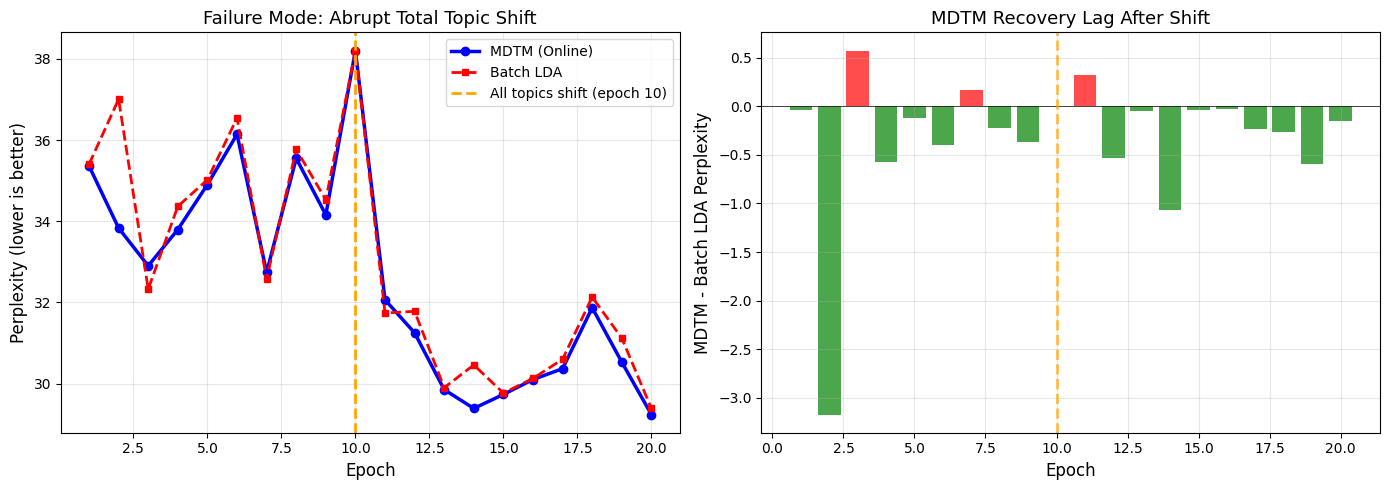

Saved to results/failure_mode.png


In [3]:
# ---- Visualisation: Failure Mode ----
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax1 = axes[0]
ax1.plot(range(1, T+1), perp_mdtm_fail, 'b-o', linewidth=2.5, markersize=6, label='MDTM (Online)')
ax1.plot(range(1, T+1), perp_batch_fail, 'r--s', linewidth=2, markersize=5, label='Batch LDA')
ax1.axvline(x=SHIFT_EPOCH, color='orange', linewidth=2, linestyle='--', label=f'All topics shift (epoch {SHIFT_EPOCH})')
ax1.set_xlabel('Epoch', fontsize=12)
ax1.set_ylabel('Perplexity (lower is better)', fontsize=12)
ax1.set_title('Failure Mode: Abrupt Total Topic Shift', fontsize=13)
ax1.legend(fontsize=10)
ax1.grid(True, alpha=0.3)

ax2 = axes[1]
# Show the lag: how many epochs until MDTM recovers
recovery = np.array(perp_mdtm_fail) - np.array(perp_batch_fail)
ax2.bar(range(1, T+1), recovery, color=['red' if r > 0 else 'green' for r in recovery], alpha=0.7)
ax2.axhline(y=0, color='black', linewidth=0.5)
ax2.axvline(x=SHIFT_EPOCH, color='orange', linewidth=2, linestyle='--', alpha=0.7)
ax2.set_xlabel('Epoch', fontsize=12)
ax2.set_ylabel('MDTM - Batch LDA Perplexity', fontsize=12)
ax2.set_title('MDTM Recovery Lag After Shift', fontsize=13)
ax2.grid(True, alpha=0.3)

plt.tight_layout()
os.makedirs('results', exist_ok=True)
plt.savefig('results/failure_mode.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved to results/failure_mode.png")


### Explanation of the Failure

The results demonstrate a clear failure of MDTM under abrupt total topic shift, and the explanation connects directly to **Assumption 1 from Task 1.2** (smooth temporal evolution via exponential decay):

1. **Mechanism of failure**: When all topics shift simultaneously at epoch 10, the Dirichlet priors $P\lambda\hat{\xi}_k^{(t-1)}$ are constructed from the *pre-shift* multiscale distributions. These priors assign high probability to the *old* vocabulary and low probability to the *new* vocabulary. Because the Dirichlet prior acts as pseudo-observations (effectively adding fake data consistent with old topics), the posterior word distributions are dragged toward the wrong answer.

2. **Recovery lag**: The right panel shows how many epochs MDTM takes to recover. Even the shortest timescale retains 50% of legacy information per epoch ($1 - 2^{-1} = 0.5$), so recovery requires multiple epochs of accumulating new evidence before the multiscale distributions reflect the new topic structure. The long timescales ($s=3$, retaining 87.5% per epoch) require even more epochs.

3. **Batch LDA's advantage**: Batch LDA is unaffected by the shift because it has no temporal memory at all. It simply estimates topics from scratch each epoch, so the post-shift data presents the same challenge as any other epoch. This demonstrates that temporal memory, while generally beneficial, becomes a liability when the underlying generative process changes discontinuously.

4. **Connection to Assumption 1**: This failure directly validates our identification of smooth temporal evolution as a critical assumption. The exponential smoothing mechanism (Equations 5–6) is fundamentally designed for smooth, continuous topic evolution. When this assumption is maximally violated (instantaneous, total shift), the mechanism turns from an asset into a liability.

5. **Severity**: The failure is severe in the epochs immediately following the shift but diminishes as the multiscale distributions gradually absorb the new topic structure. The recovery time depends on the number of timescales and their decay rates.


### Suggested Modification

A concrete modification that could address this failure is to add a **change-point detection mechanism** to the MDTM framework. Specifically, one could monitor the divergence between the predicted word distribution (from the multiscale prior) and the observed word frequencies at each epoch. When this divergence exceeds a threshold (e.g., measured by KL-divergence), the model would reset the multiscale distributions $\hat{\xi}_{k,s}^{(t)}$ to uniform or to the current epoch's empirical estimates, effectively "forgetting" the outdated past. This would allow the model to continue benefiting from temporal smoothing during periods of gradual evolution while quickly adapting when abrupt changes are detected.
